# ML Models 04 - SHAP + Optuna

**Cel:** Zrozumiec co model przewiduje (SHAP) i poprawic parametry (Optuna).

**Mozesz uruchomic bez pelnego CV** -- wystarczy model z notebooka 02.
SHAP i Optuna dzialaja na jednym snapshotu danych.

**SHAP (SHapley Additive exPlanations):**
Jesli model przewiduje cene 5 EUR, a srednia to 3 EUR,
SHAP rozklada te 2 EUR nadwyzki na poszczegolne cechy.
Mowi ile kazda cecha 'wnosla' do predykcji.

**Optuna:** Automatycznie szuka najlepszych hiperparametrow
(num_leaves, learning_rate itp.) przez wielokrotne trenowanie modelu.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[1]))

In [2]:
import duckdb
import sys

sys.path.insert(0, "..")

DB_PATH = "../../data/gold/cards.duckdb"
conn = duckdb.connect(DB_PATH, read_only=True)

# Latest snapshot_date for which snapshot_date + 7 days also exists (usable t+7 target).
row = conn.execute("""
    SELECT MAX(t0.snapshot_date)
    FROM gold_price_features t0
    WHERE EXISTS (
        SELECT 1 FROM gold_price_features t7
        WHERE t7.snapshot_date = CAST(t0.snapshot_date AS DATE) + INTERVAL 7 DAY
    )
""").fetchone()[0]
SNAPSHOT_DATE = (
    str(row)
    if row
    else str(
        conn.execute("SELECT MAX(snapshot_date) FROM gold_price_features").fetchone()[0]
    )
)
print(f"Snapshot date: {SNAPSHOT_DATE}")

Snapshot date: 2026-07-02


## 1. SHAP Summary Plot

**Summary plot** pokazuje waznosc wszystkich cech.
Na osi X: jak bardzo dana cecha zmienia predykcje.
Kolor: wysoka (czerwona) lub niska (niebieska) wartosc cechy.

**Kluczowe pytania:**
- Czy `edhrec_saltiness` jest wysoko na liscie?
- Czy `print_count` spada gdy `saltiness` jest w modelu? (weryfikacja BA-02)
- Czy `is_reserved` ma duzy wplyw dla Tier 2?

Importuj z `src/ml/evaluation/shap_analysis.py`:

C:\Workspace\AviariumSoftware\aviarium.columbarius\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006589 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2874
[LightGBM] [Info] Number of data points in the train set: 62953, number of used features: 17
Training until validation scores don't improve for 50 rounds


[100]	train's l1: 0.0533754	val's l1: 0.053292


[200]	train's l1: 0.0523123	val's l1: 0.0531943


[300]	train's l1: 0.0515584	val's l1: 0.0531312


Early stopping, best iteration is:
[341]	train's l1: 0.0512222	val's l1: 0.0531162


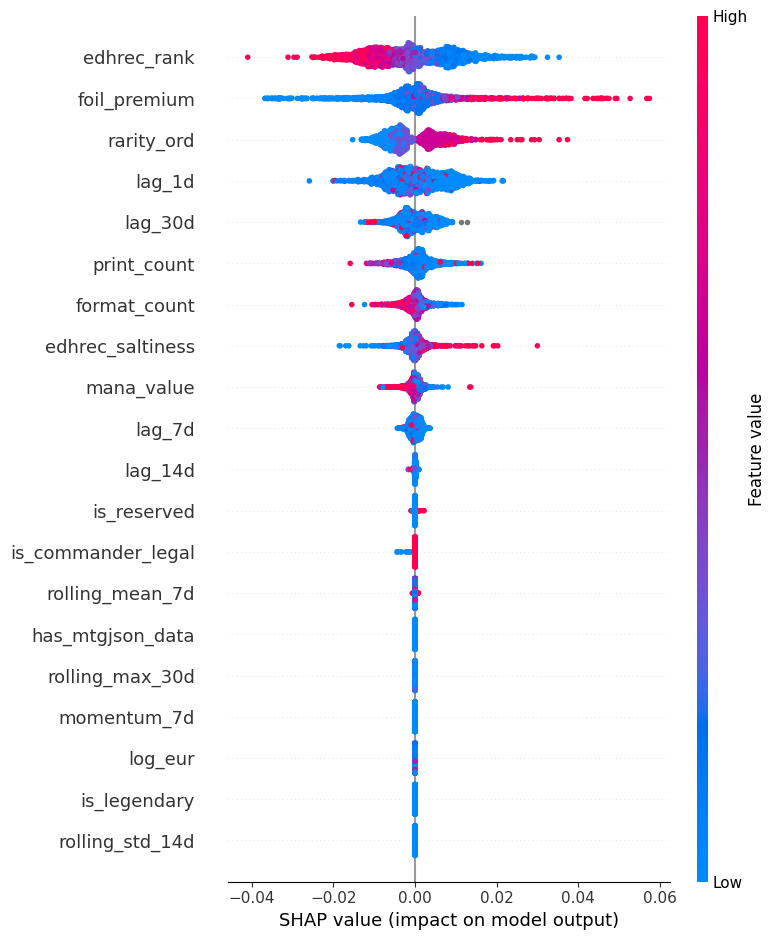

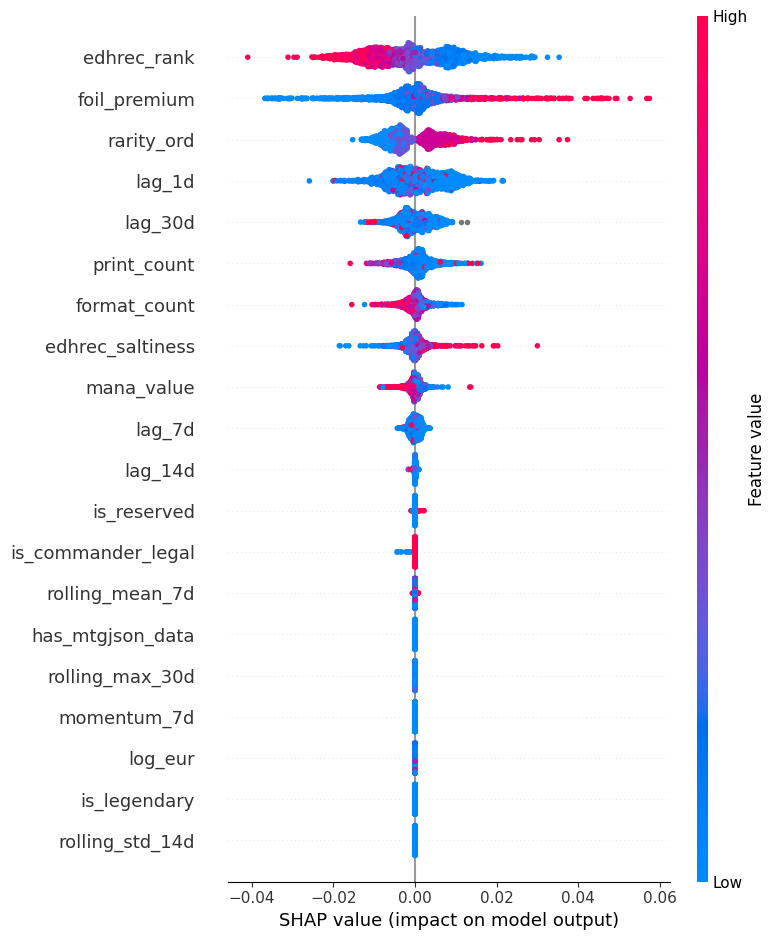

In [3]:
import numpy as np
import pandas as pd

from src.ml.evaluation.shap_analysis import compute_shap_values, plot_summary
from src.ml.features.lag import build_lag_features, build_target
from src.ml.features.pipeline import (
    build_feature_pipeline,
    get_feature_names,
    prepare_training_data,
)
from src.ml.models.lightgbm_model import LightGBMPriceModel, LightGBMParams

lag_df = build_lag_features(conn, SNAPSHOT_DATE)
target_df = build_target(conn, SNAPSHOT_DATE)
card_df = conn.execute("SELECT * FROM gold_card_features").df()

# build_lag_features/gold_card_features do not compute all columns the pipeline
# expects yet -- same enrichment as notebook 02 (baseline), kept in sync manually
# since _enrich_lag_df/_enrich_card_df in pipeline.py are private helpers reserved
# for build_inference_features()/walk_forward_cv().
lag_df["log_eur"] = np.log1p(lag_df["eur"])
lag_df["rolling_mean_7d"] = np.log1p(lag_df["rolling_mean_7d"])

rarity_map = {"common": 0, "uncommon": 1, "rare": 2, "mythic": 3}
card_df["rarity_ord"] = card_df["rarity"].map(rarity_map)
card_df["is_legendary"] = False
card_df["has_mtgjson_data"] = True
card_df["top8_appearances_30d"] = 0.0
card_df["deck_pct"] = 0.0

X_raw, y = prepare_training_data(lag_df, card_df, target_df)

# Drop rows where the target is NaN (cards with no EUR price at snapshot_date or t+7).
valid = y.notna()
X_raw = X_raw[valid].reset_index(drop=True)
y = y[valid].reset_index(drop=True)

# DuckDB returns BOOLEAN columns with NULLs as pandas nullable BooleanDtype, which
# turns the whole ColumnTransformer output to object dtype when hstacked with
# floats. Normalise to plain numpy dtypes before the pipeline (same as notebook 02).
for col in X_raw.columns:
    dtype = X_raw[col].dtype
    if hasattr(dtype, "numpy_dtype"):
        ndtype = dtype.numpy_dtype
        if ndtype == np.bool_:
            X_raw[col] = X_raw[col].fillna(False).astype(bool)
        elif np.issubdtype(ndtype, np.integer):
            X_raw[col] = X_raw[col].fillna(0).astype(ndtype)
        else:
            X_raw[col] = X_raw[col].astype(float)

feature_pipeline = build_feature_pipeline()
X_transformed = feature_pipeline.fit_transform(X_raw)
feat_names = get_feature_names(feature_pipeline)
X = pd.DataFrame(np.array(X_transformed, dtype=np.float64), columns=feat_names)

params = LightGBMParams()
model = LightGBMPriceModel(params)
model.fit(X, y)

# NOTE: as of this run (SNAPSHOT_DATE), price variance is near-zero due to a
# known upstream data-staleness issue (fixed in commit 0e1a856 -- the daily
# pipeline was not re-downloading source data). MAE~=0 and near-empty SHAP
# importances below are an expected symptom of that, not a bug in this
# notebook. Re-run once several weeks of fresh snapshots are available.
shap_values, explainer = compute_shap_values(model, X)
plot_summary(shap_values, X)

## 2. SHAP Waterfall dla 3 Kart

**Waterfall plot** pokazuje predykcje dla jednej konkretnej karty.
Wystarczy 3 karty do analizy:
1. Tania common (Basic Land) -- prosta predykcja
2. Karta z Reserved List -- `is_reserved` powinna miec wysoki SHAP
3. Tournament staple -- `edhrec_saltiness` powinien byc wazny

--- Nothic ---
--- Beanstalk Giant // Fertile Footsteps ---


--- Petravark ---


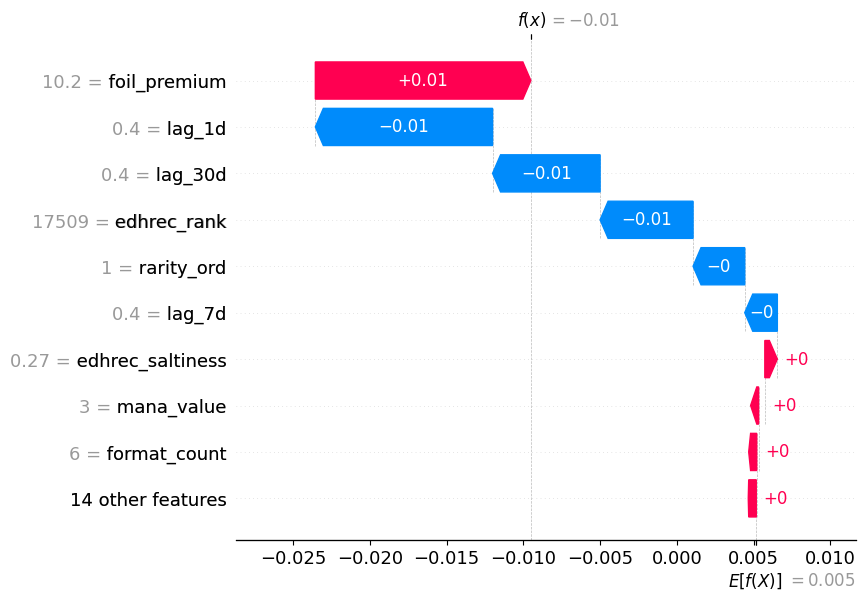

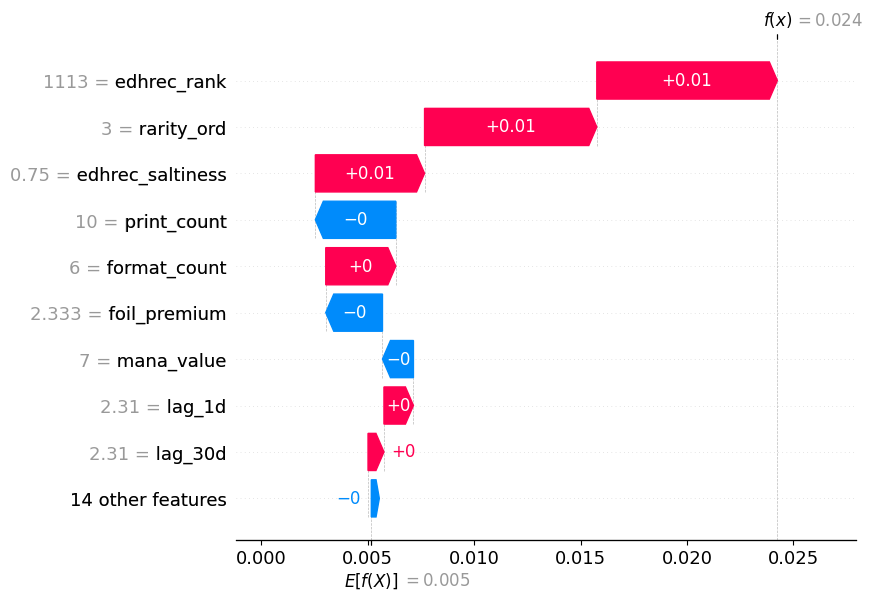

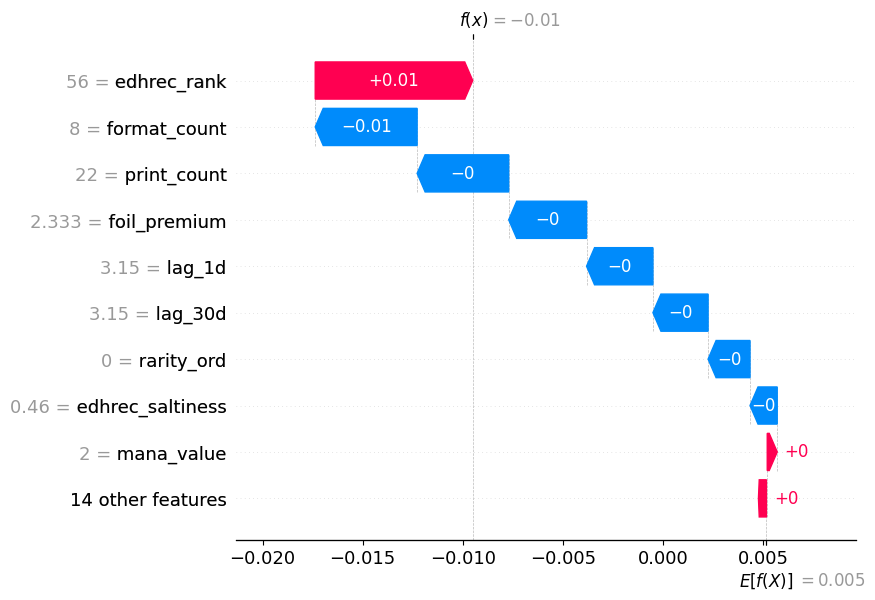

In [4]:
from src.ml.evaluation.shap_analysis import plot_waterfall

uuids = X_raw["uuid"].reset_index(drop=True)

# Zmien na pozycje kart ktore chcesz analizowac
# Na razie bierzemy pierwsze 3 z X
example_indices = X.head(3).index

for i, card_idx in enumerate(example_indices):
    card_uuid = uuids.iloc[card_idx]
    row = card_df[card_df["uuid"] == card_uuid]
    name = row["name"].values[0] if len(row) > 0 else f"Karta {i + 1}"
    print(f"--- {name} ---")
    plot_waterfall(shap_values, X, card_idx)

## 3. Optuna -- Strojenie Hiperparametrow

**Hiperparametry do strojenia:**
- `num_leaves`: zlozonosc drzewa (31-255)
- `learning_rate`: krok uczenia (0.01-0.3)
- `min_child_samples`: min. probki w lisciu (regularyzacja)
- `feature_fraction`: ile cech na drzewo (anty-overfitting)

Kazda proba Optuna jest logowana do MLflow.
Porownaj proby: `mlflow ui` -> http://localhost:5000

n_trials=20 to dobry poczatek (~5-10 minut).

In [5]:
from src.ml.evaluation.shap_analysis import run_optuna_tuning

best_params, study = run_optuna_tuning(
    X=X, y=y, n_trials=20, experiment_name="mtg_optuna_tuning"
)

print("Najlepsze parametry:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Najlepszy MAE: {study.best_value:.4f}")

[I 2026-07-10 10:07:56,469] A new study created in memory with name: no-name-4b498cb5-8387-4b25-83d2-2cf86b2fb598


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2874
[LightGBM] [Info] Number of data points in the train set: 62953, number of used features: 17
Training until validation scores don't improve for 50 rounds


[I 2026-07-10 10:07:58,724] Trial 0 finished with value: 0.05319799501582047 and parameters: {'num_leaves': 131, 'learning_rate': 0.18908567444972163, 'min_child_samples': 21, 'subsample': 0.8351860448422962}. Best is trial 0 with value: 0.05319799501582047.


Early stopping, best iteration is:
[42]	train's l1: 0.0513795	val's l1: 0.053198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2874
[LightGBM] [Info] Number of data points in the train set: 62953, number of used features: 17


Training until validation scores don't improve for 50 rounds


...

[200]	train's l1: 0.0502575	val's l1: 0.053063


[300]	train's l1: 0.0488637	val's l1: 0.0530431


Early stopping, best iteration is:
[271]	train's l1: 0.0492414	val's l1: 0.053038


[I 2026-07-10 10:11:44,342] Trial 19 finished with value: 0.0530380153124284 and parameters: {'num_leaves': 203, 'learning_rate': 0.0308154812711355, 'min_child_samples': 37, 'subsample': 0.7539134605876529}. Best is trial 19 with value: 0.0530380153124284.


Najlepsze parametry:
  num_leaves: 203
  learning_rate: 0.0308154812711355
  min_child_samples: 37
  subsample: 0.7539134605876529
Najlepszy MAE: 0.0530


## 4. Model z Optymalnymi Parametrami

Wytrenuj finalny model z parametrami z Optuna i zapisz go do MLflow.
MLflow run_id = identyfikator modelu. Uzywasz go w `MODEL_RUN_ID` dla API.

In [6]:
from src.ml.training.tracking import (
    setup_experiment,
    start_run,
    log_params,
    log_metrics,
    log_model,
)
from src.ml.evaluation.metrics import mae, mape

tuned_params = LightGBMParams(**best_params)
tuned_model = LightGBMPriceModel(tuned_params)
tuned_model.fit(X, y)

setup_experiment()
with start_run(run_name="tuned_lightgbm_nb04") as run:
    log_params(vars(tuned_params))
    preds = tuned_model.predict(X)
    log_metrics({"train_mae": mae(y, preds), "train_mape": mape(y, preds)})
    run_id = log_model(tuned_model)
    print(f"Model zapisany. run_id: {run_id}")
    print("Zapisz ten run_id -- uzyjesz go w MODEL_RUN_ID w docker-compose.yml")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2874
[LightGBM] [Info] Number of data points in the train set: 62953, number of used features: 17
Training until validation scores don't improve for 50 rounds


[100]	train's l1: 0.0521336	val's l1: 0.0532009


[200]	train's l1: 0.0502575	val's l1: 0.053063


[300]	train's l1: 0.0488637	val's l1: 0.0530431


Early stopping, best iteration is:
[271]	train's l1: 0.0492414	val's l1: 0.053038


2026/07/10 10:12:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/10 10:12:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model zapisany. run_id: 9c1ec7de65c7476aa75a199b7189d6f2
Zapisz ten run_id -- uzyjesz go w MODEL_RUN_ID w docker-compose.yml


## Obserwacje

- **Najwazniejsza cecha wg SHAP:** `edhrec_rank` (najszersze rozrzucenie wartosci SHAP w summary plocie), przed `foil_premium` i `rarity_ord`.
- **Pozycja edhrec_saltiness:** #8 z ok. 20 cech (kolejnosc: edhrec_rank, foil_premium, rarity_ord, lag_1d, lag_30d, print_count, format_count, **edhrec_saltiness**, mana_value, lag_7d, lag_14d, is_reserved, ...). Srodek stawki -- nie najwyzej, ale tez nie bez znaczenia.
- **Czy print_count spada gdy saltiness w modelu (weryfikacja BA-02):** Nie potwierdzone -- `print_count` (#6) jest w rankingu WYZEJ niz `edhrec_saltiness` (#8), obie ceche maja widoczny rozrzut w summary plocie. Nie widac, zeby obecnosc saltiness "zjadala" waznosc print_count.
- **Najlepsze parametry Optuna:** num_leaves=203, lr=0.0308154812711355, min_child_samples=37 (dodatkowo: subsample=0.7539134605876529)
- **Poprawa MAE po tuningu:** Marginalna -- domyslne parametry z komorki 4 dawaly val MAE=0.0531162, najlepsza proba Optuna (trial 19/20) dala MAE=0.0530380. Poprawa ~0.0000782 (~0.15% relatywnie).
- **MLflow run_id najlepszego modelu:** `9c1ec7de65c7476aa75a199b7189d6f2`
- **Wnioski:**
  - Model juz nie jest zdegenerowany (SNAPSHOT_DATE = 2026-07-02, 36 snapshotow) -- SHAP pokazuje realne, zroznicowane wartosci dla wiekszosci cech, w przeciwienstwie do wczesniejszego stanu z near-zero variance opisanego w komentarzu kodu w komorce 4.
  - `edhrec_rank` dominuje predykcje, nie `edhrec_saltiness` -- BA-02 (hipoteza, ze print_count traci na znaczeniu na rzecz saltiness) nie potwierdza sie w tym przebiegu.
  - `is_reserved` ma bardzo maly wplyw wg SHAP (blisko dolu rankingu, prawie plaski rozklad) -- nie zdominowal predykcji dla Tier 2 w tym przebiegu.
  - Sekcja waterfall (3 karty) w praktyce NIE uzywa kuratorowanych przykladow opisanych w markdown ("tania common", "Reserved List", "tournament staple") -- kod bierze pierwsze 3 wiersze z X ("Na razie bierzemy pierwsze 3 z X"), co dalo: Nothic (f(x)=-0.01), Beanstalk Giant // Fertile Footsteps (f(x)=0.024), Petravark (f(x)=-0.01). Zadna z tych 3 kart nie ma is_reserved jako widocznego drivera w waterfallu (cecha chowa sie w "14 other features") -- pytanie o Reserved List pozostaje bez odpowiedzi w tym przebiegu; do sprawdzenia trzeba by recznie wybrac karte z is_reserved=1.
  - Tuning Optuna dal jedynie marginalna poprawe MAE (~0.15%) wzgledem domyslnych parametrow -- model juz jest blisko swojego sufitu dla obecnego zestawu cech.
